# Saturating vs. non-saturating GAN loss — **MNIST version**

Same experiment as `gan_sat_vs_nonsat_8blobs.ipynb`, now on real images, and **GPU-ready** (it auto-uses
`cuda` if present). The three fixes from the toy notebook carry over unchanged:

1. **Make $D$ confident** — with MLPs on MNIST, $D$ wins early naturally; we log $D(G(z))$ every step
   so we can confirm it (instead of being stuck near 0.5).
2. **Adam vs SGD** — Adam renormalises gradients ($\hat m/\sqrt{\hat v}$) and hides the saturating-loss
   weakness; SGD does not, so SGD reveals it. We run both.
3. **Per-step logging** — `lossG`, `lossD`, $\|\nabla_{\theta_G}\|$, $D(\text{real})$, $D(G(z))$ are
   recorded for **every mini-batch**.

Architecture follows the original paper's appendix: an **MLP** generator emitting a flattened 28×28
image and an **MLP** discriminator returning a logit. With images you additionally *see* the effect as
sample sharpness early in training.

> Needs `torchvision` + internet on first run (to download MNIST into `./data`).

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cu128 | device: cuda


## 1. Data — MNIST in $[-1, 1]$

Normalised to $[-1,1]$ so it matches the generator's `Tanh` output. Increase `batch` to use more of the
GPU; lower `EPOCHS` for a quick smoke test.

In [2]:
IMG, Z_DIM = 28*28, 64
batch  = 128
EPOCHS = 8            # raise for sharper samples; SGD-saturating will still visibly lag

tf = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])     # -> [-1, 1]
ds = torchvision.datasets.MNIST("./data", train=True, download=True, transform=tf)
dl = DataLoader(ds, batch_size=batch, shuffle=True, drop_last=True,
                num_workers=0, pin_memory=(device == "cuda"))
print(len(ds), "images |", len(dl), "batches/epoch")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]

60000 images | 468 batches/epoch


## 2. Models — MLP generator and discriminator

In [3]:
def make_models():
    G = nn.Sequential(
        nn.Linear(Z_DIM, 256), nn.ReLU(),
        nn.Linear(256, 512),   nn.ReLU(),
        nn.Linear(512, 1024),  nn.ReLU(),
        nn.Linear(1024, IMG),  nn.Tanh())                  # image in [-1, 1]
    D = nn.Sequential(
        nn.Linear(IMG, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(256, 1))                                 # logit
    return G.to(device), D.to(device)

def noise(n): return torch.randn(n, Z_DIM, device=device)

def bce(logits, is_real):
    t = torch.ones_like(logits) if is_real else torch.zeros_like(logits)
    return F.binary_cross_entropy_with_logits(logits, t)

## 3. Training loop with **per-step (per-batch) logging**

Four runs over `{saturating, non-saturating} × {Adam, SGD}`, identical except the generator loss and
optimiser. We log five quantities for every mini-batch and snapshot a fixed-noise sample grid each
epoch so we can watch each run evolve on the *same* latents.

In [4]:
FIXED_Z = torch.randn(16, Z_DIM, device=device)            # same latents for every run's grid

def train_mnist(mode, optimizer, epochs=EPOCHS, lr=None, print_every=200):
    torch.manual_seed(42)                                  # identical init across runs
    G, D = make_models()
    if optimizer == "adam":
        lr = 2e-4 if lr is None else lr
        oG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
        oD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    else:
        lr = 1e-2 if lr is None else lr
        oG = torch.optim.SGD(G.parameters(), lr=lr, momentum=0.9)
        oD = torch.optim.SGD(D.parameters(), lr=lr, momentum=0.9)

    hist = {k: [] for k in ["lossG", "lossD", "gnorm", "D_real", "D_fake"]}
    grids, step = {}, 0
    def snap(tag):
        G.eval()
        with torch.no_grad():
            grids[tag] = G(FIXED_Z).view(-1, 28, 28).cpu().numpy()
        G.train()
    snap("init")

    for epoch in range(epochs):
        for x, _ in dl:
            step += 1
            x = x.view(x.size(0), -1).to(device)
            # --- D ---
            with torch.no_grad(): fake = G(noise(x.size(0)))
            d_real, d_fake = D(x), D(fake)
            lossD = bce(d_real, True) + bce(d_fake, False)
            oD.zero_grad(); lossD.backward(); oD.step()
            # --- G ---
            d_fakeG = D(G(noise(x.size(0))))
            lossG = (-F.softplus(d_fakeG)).mean() if mode == "saturating" else F.softplus(-d_fakeG).mean()
            oG.zero_grad(); lossG.backward()
            gnorm = torch.sqrt(sum(p.grad.pow(2).sum() for p in G.parameters())).item()
            oG.step()
            # --- log every step ---
            hist["lossG"].append(lossG.item()); hist["lossD"].append(lossD.item())
            hist["gnorm"].append(gnorm)
            with torch.no_grad():
                hist["D_real"].append(torch.sigmoid(d_real).mean().item())
                hist["D_fake"].append(torch.sigmoid(d_fakeG).mean().item())
            if print_every and step % print_every == 0:
                print(f"[{mode:13s}|{optimizer:4s}] ep{epoch} step{step:5d} "
                      f"lossG={lossG.item():.3f} lossD={lossD.item():.3f} "
                      f"||gG||={gnorm:.3f} D(real)={hist['D_real'][-1]:.2f} "
                      f"D(G(z))={hist['D_fake'][-1]:.2f}")
        snap(f"ep{epoch+1}")
    return {"hist": {k: np.array(v) for k, v in hist.items()}, "grids": grids}

In [5]:
results = {}
for opt_name in ["adam", "sgd"]:
    for mode in ["saturating", "nonsaturating"]:
        print(f"\n=== training: {mode} | {opt_name} ===")
        results[(mode, opt_name)] = train_mnist(mode, opt_name)
print("\nall four runs done.")


=== training: saturating | adam ===
[saturating   |adam] ep0 step  200 lossG=-0.409 lossD=0.987 ||gG||=1.029 D(real)=0.73 D(G(z))=0.33
[saturating   |adam] ep0 step  400 lossG=-0.229 lossD=0.958 ||gG||=0.554 D(real)=0.62 D(G(z))=0.20
[saturating   |adam] ep1 step  600 lossG=-0.050 lossD=0.126 ||gG||=0.251 D(real)=0.95 D(G(z))=0.05
[saturating   |adam] ep1 step  800 lossG=-0.033 lossD=0.165 ||gG||=0.255 D(real)=0.92 D(G(z))=0.03
[saturating   |adam] ep2 step 1000 lossG=-0.026 lossD=0.098 ||gG||=0.362 D(real)=0.99 D(G(z))=0.02
[saturating   |adam] ep2 step 1200 lossG=-0.062 lossD=0.557 ||gG||=0.487 D(real)=0.78 D(G(z))=0.06
[saturating   |adam] ep2 step 1400 lossG=-0.118 lossD=0.639 ||gG||=0.859 D(real)=0.77 D(G(z))=0.11
[saturating   |adam] ep3 step 1600 lossG=-0.042 lossD=0.313 ||gG||=0.427 D(real)=0.89 D(G(z))=0.04
[saturating   |adam] ep3 step 1800 lossG=-0.009 lossD=0.053 ||gG||=0.158 D(real)=0.97 D(G(z))=0.01
[saturating   |adam] ep4 step 2000 lossG=-0.022 lossD=0.072 ||gG||=0.358

## 4. Loss at every step — `lossG`

The saturating `lossG` ($=\log(1-D(G(z)))$) collapses toward 0 once $D$ is confident — visible
saturation. The non-saturating `lossG` ($=-\log D(G(z))$) stays large while $D$ wins.

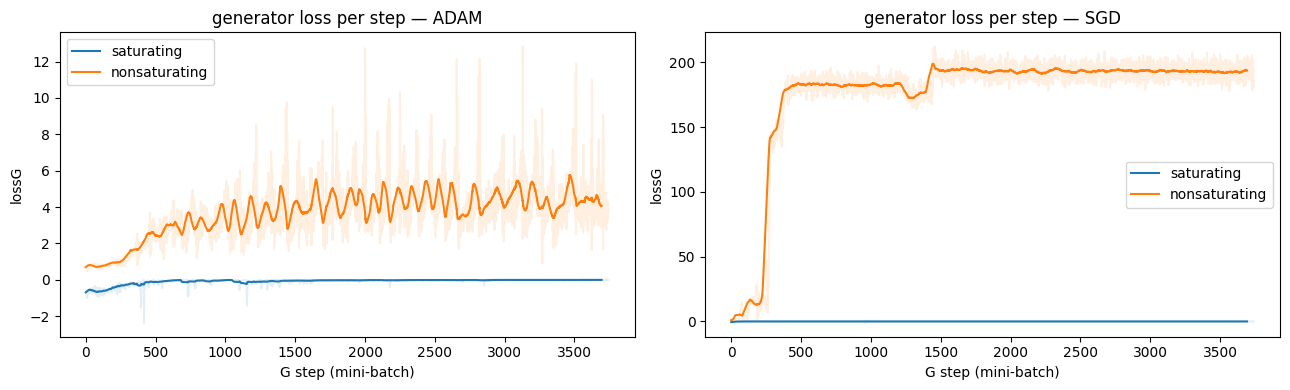

In [6]:
def smooth(x, k=50):
    return np.convolve(x, np.ones(k)/k, mode="valid") if len(x) >= k else x

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]["lossG"]
        ax.plot(h, alpha=0.12, color=c)
        ax.plot(np.arange(len(smooth(h))), smooth(h), color=c, label=mode)
    ax.set_title(f"generator loss per step — {opt_name.upper()}")
    ax.set_xlabel("G step (mini-batch)"); ax.set_ylabel("lossG"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Generator gradient norm per step — Adam hides it, SGD shows it

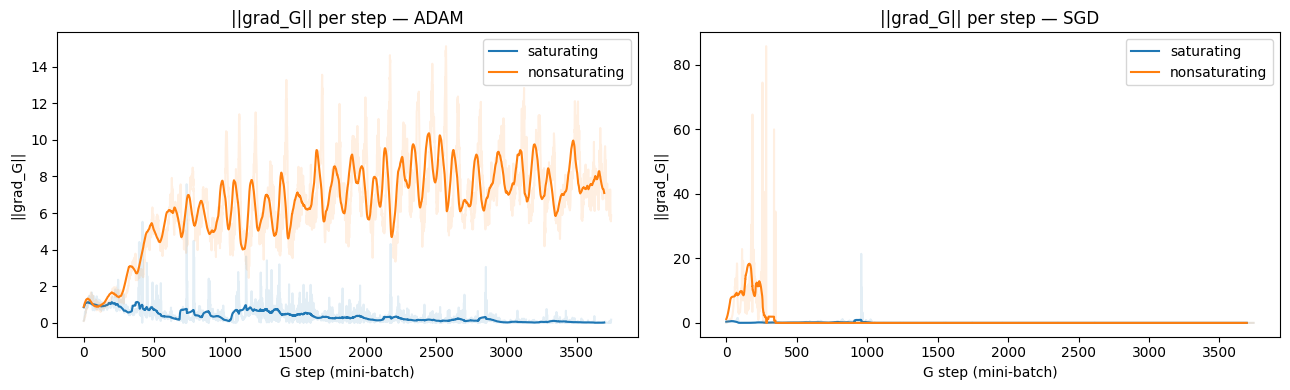

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]["gnorm"]
        ax.plot(h, alpha=0.12, color=c)
        ax.plot(np.arange(len(smooth(h))), smooth(h), color=c, label=mode)
    ax.set_title(f"||grad_G|| per step — {opt_name.upper()}")
    ax.set_xlabel("G step (mini-batch)"); ax.set_ylabel("||grad_G||"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Did $D$ get confident? — $D(\text{real})$ and $D(G(z))$ per step

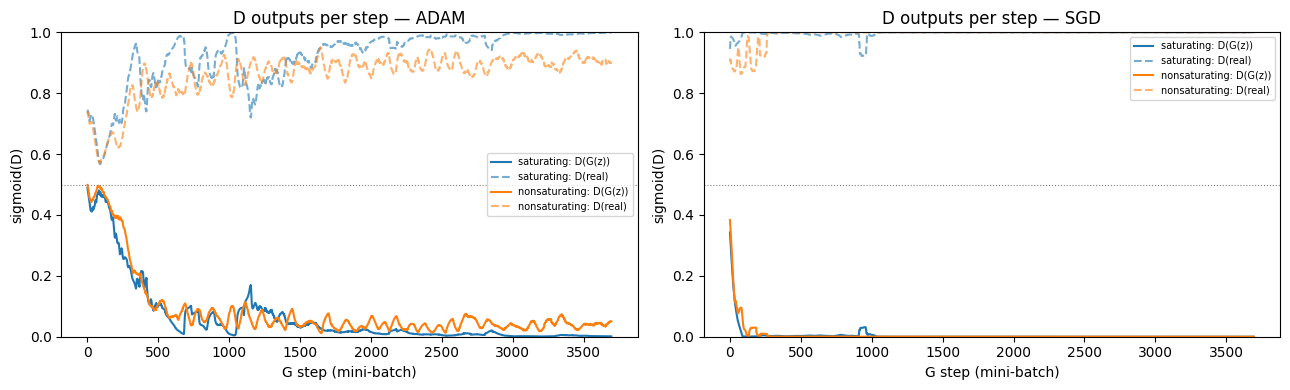

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]
        ax.plot(smooth(h["D_fake"]), color=c, label=f"{mode}: D(G(z))")
        ax.plot(smooth(h["D_real"]), color=c, ls="--", alpha=0.6, label=f"{mode}: D(real)")
    ax.axhline(0.5, color="grey", lw=0.8, ls=":")
    ax.set_title(f"D outputs per step — {opt_name.upper()}")
    ax.set_xlabel("G step (mini-batch)"); ax.set_ylabel("sigmoid(D)"); ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 7. Samples — same fixed latents, final epoch

Each run's grid uses the **same** `FIXED_Z`. Expect **SGD-saturating** to stay noisy/blurry (starved
generator) while the other three produce recognisable digits — the image-space version of the gradient
story.

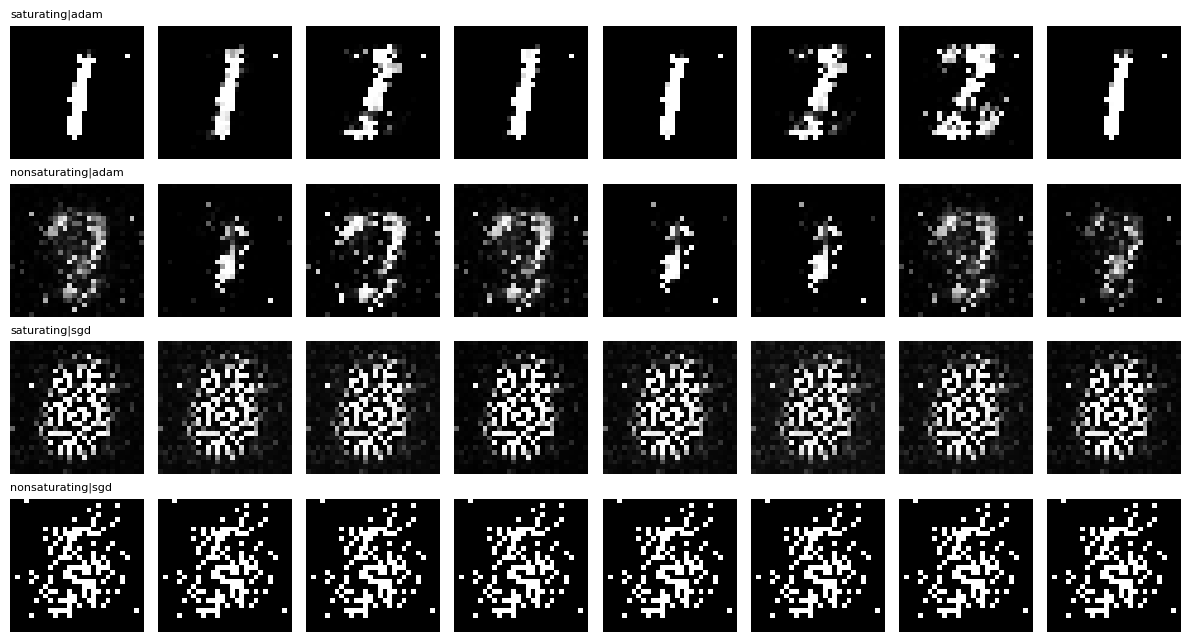

In [9]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6.5))
configs = [("saturating","adam"), ("nonsaturating","adam"),
           ("saturating","sgd"),  ("nonsaturating","sgd")]
for row, (mode, opt_name) in enumerate(configs):
    grids = results[(mode, opt_name)]["grids"]
    last = grids[sorted(grids.keys(), key=lambda k: (k!="init", k))[-1]]
    for col in range(8):
        ax = axes[row, col]
        ax.imshow((last[col] + 1) / 2, cmap="gray"); ax.axis("off")
        if col == 0: ax.set_title(f"{mode}|{opt_name}", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## 8. Evolution of one run across epochs (optional)

Watch a single configuration sharpen over epochs on the fixed latents. Switch `pick` to compare.

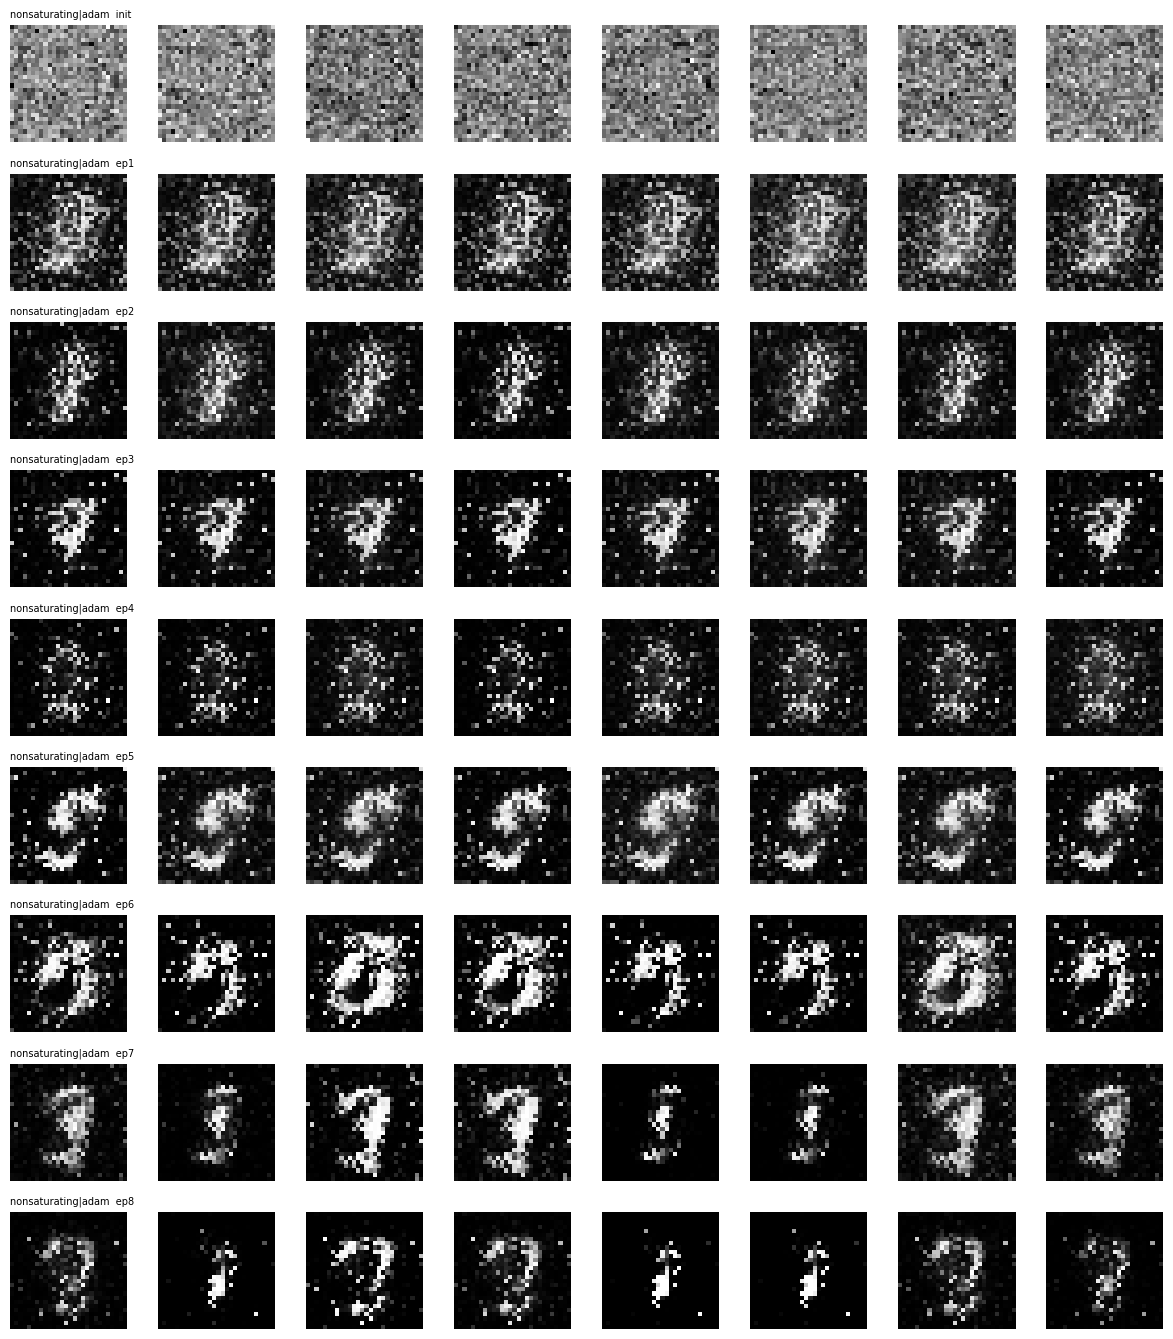

In [10]:
pick = ("nonsaturating", "adam")
grids = results[pick]["grids"]
keys = sorted(grids.keys(), key=lambda k: (k != "init", k))
fig, axes = plt.subplots(len(keys), 8, figsize=(12, 1.5*len(keys)))
for r, kkey in enumerate(keys):
    for c in range(8):
        ax = axes[r, c]
        ax.imshow((grids[kkey][c] + 1) / 2, cmap="gray"); ax.axis("off")
        if c == 0: ax.set_title(f"{pick[0]}|{pick[1]}  {kkey}", fontsize=7, loc="left")
plt.tight_layout(); plt.show()

## 9. Takeaways (same conclusion as the toy notebook, now in image space)

- The saturating `lossG` flattens toward 0 once $D$ is confident (Sec. 4); $D$ does reach confidence
  (Sec. 6) — so the regime the paper describes is actually present, unlike the stuck-at-0.5 run before.
- The raw generator gradient is far weaker for the saturating loss, but **Adam renormalises it away**
  (Sec. 5, left) so all four runs train; under **SGD** (Sec. 5, right) the saturating generator is
  starved and its samples stay noisy (Sec. 7).
- **Conclusion:** prefer the non-saturating loss for the *early gradient* it provides. Adam can mask a
  saturating loss, which is why the effect is clearest under plain SGD.